# Gulf States Gas Flares — VNF-style Planck Fitting

VIIRS Nightfire methodology (Elvidge et al. 2013, VNF v4.0) adapted for FIRMS I-band data.

**Algorithm**: Two-component sub-pixel Planck model with FRP constraint + atmospheric correction.  
**Calibration**: Tunable parameters (`CalibrationConfig`) for alignment with VNF reference data.  
**Output**: VNF-compatible columns — `Temp_BB`, `ESF`, `source_area`, `RHI`, `RH`, `QF`.

In [1]:
from pathlib import Path
from flare_analysis import (
    CalibrationConfig,
    download_firms, load_and_process, vnf_planck_fit,
    build_monthly_timeseries, apply_scale_factors,
    plot_timeseries_bars, plot_hightemp_map, plot_diagnostics,
    compare_with_reference, plot_calibration, auto_calibrate,
    export_csv,
)

## 1. Configuration + Calibration Parameters

In [2]:
PARQUET_PATH = Path("data/raw_gulf_oct22_oct23.parquet")
OUTPUT_DIR = Path("data")

COUNTRY_BBOX = {
    "Kuwait":        (46.5, 28.5, 48.5, 30.1),
    "Iraq":          (38.8, 29.0, 48.6, 37.4),
    "Iran":          (44.0, 25.0, 63.3, 39.8),
    "Saudi Arabia":  (34.5, 16.3, 55.7, 32.2),
    "UAE":           (51.5, 22.6, 56.4, 26.1),
    "Qatar":         (50.7, 24.4, 51.7, 26.2),
    "Bahrain":       (50.3, 25.7, 50.8, 26.3),
    "Oman":          (51.8, 16.6, 59.8, 26.4),
    "Yemen":         (42.5, 12.1, 54.5, 19.0),
}

MAP_DATE_START = "2023-06-01"
MAP_DATE_END   = "2023-06-07"

# ── CALIBRATION ──────────────────────────────────────────────────
# Tune these when you have VNF reference data.
# Save/load: cal.save("data/calibration.json") / CalibrationConfig.load(...)
cal = CalibrationConfig(
    tau_i4=0.85,          # atmospheric transmittance at 3.74µm (0.5-1.0)
    tau_i5=0.90,          # atmospheric transmittance at 11.45µm (0.5-1.0)
    frp_scale=1.0,        # FIRMS FRP multiplier (tune vs VNF RH)
    bg_offset_K=0.0,      # background temperature offset [K]
    pixel_area=375*375,   # I-band pixel footprint [m²]
    T_min=600,            # min fitting temperature [K]
    T_max=6000,           # max fitting temperature [K] (VNF range)
    min_frp=0.5,          # minimum FRP filter [MW]
    confidence_filter={"n", "h"},
)
print(cal)

CalibrationConfig(tau_i4=0.85, tau_i5=0.9, T_min=600, T_max=6000, frp_scale=1.0, bg_offset_K=0.0, pixel_area=140625, min_frp=0.5, confidence_filter={'n', 'h'}, min_esf=1e-08, max_esf=1.0, min_temp=600.0, max_temp=6000.0)


## 1b. Download data (run once, then skip)

Requires `config.py` with your `FIRMS_MAP_KEY`. Skip this cell if parquet already exists.

In [3]:
if not PARQUET_PATH.exists():
    from config import FIRMS_MAP_KEY
    download_firms(
        api_key=FIRMS_MAP_KEY,
        bbox="44,16,60,36",
        start_date="2022-10-01",
        end_date="2023-06-07",
        output_path=PARQUET_PATH,
    )
else:
    print(f"Data exists: {PARQUET_PATH}")

Data exists: data\raw_gulf_oct22_oct23.parquet


## 2. Load & process (VNF Planck fitting)

In [4]:
df = load_and_process(PARQUET_PATH, COUNTRY_BBOX, cal=cal)

Loaded: 502,025 rows
Filtered: 502,025 -> 372,779
VNF Planck fitting: 372,779 pixels (tau_i4=0.85, tau_i5=0.9, frp_scale=1.0, bg_offset=0.0K)
  Fitted: 368,606 good (QF=0), 4,154 boundary (QF=1), 1 bad_esf (QF=2), 18 no_signal (QF=3)
  T range: 610 – 5989 K
  ESF range: 6.25e-07 – 1.73e-02
  RH range: 0.500 – 163.530 MW
Result: 328,094 detections, 7 countries


## 2b. Diagnostics — temperature distribution, ESF, quality flags

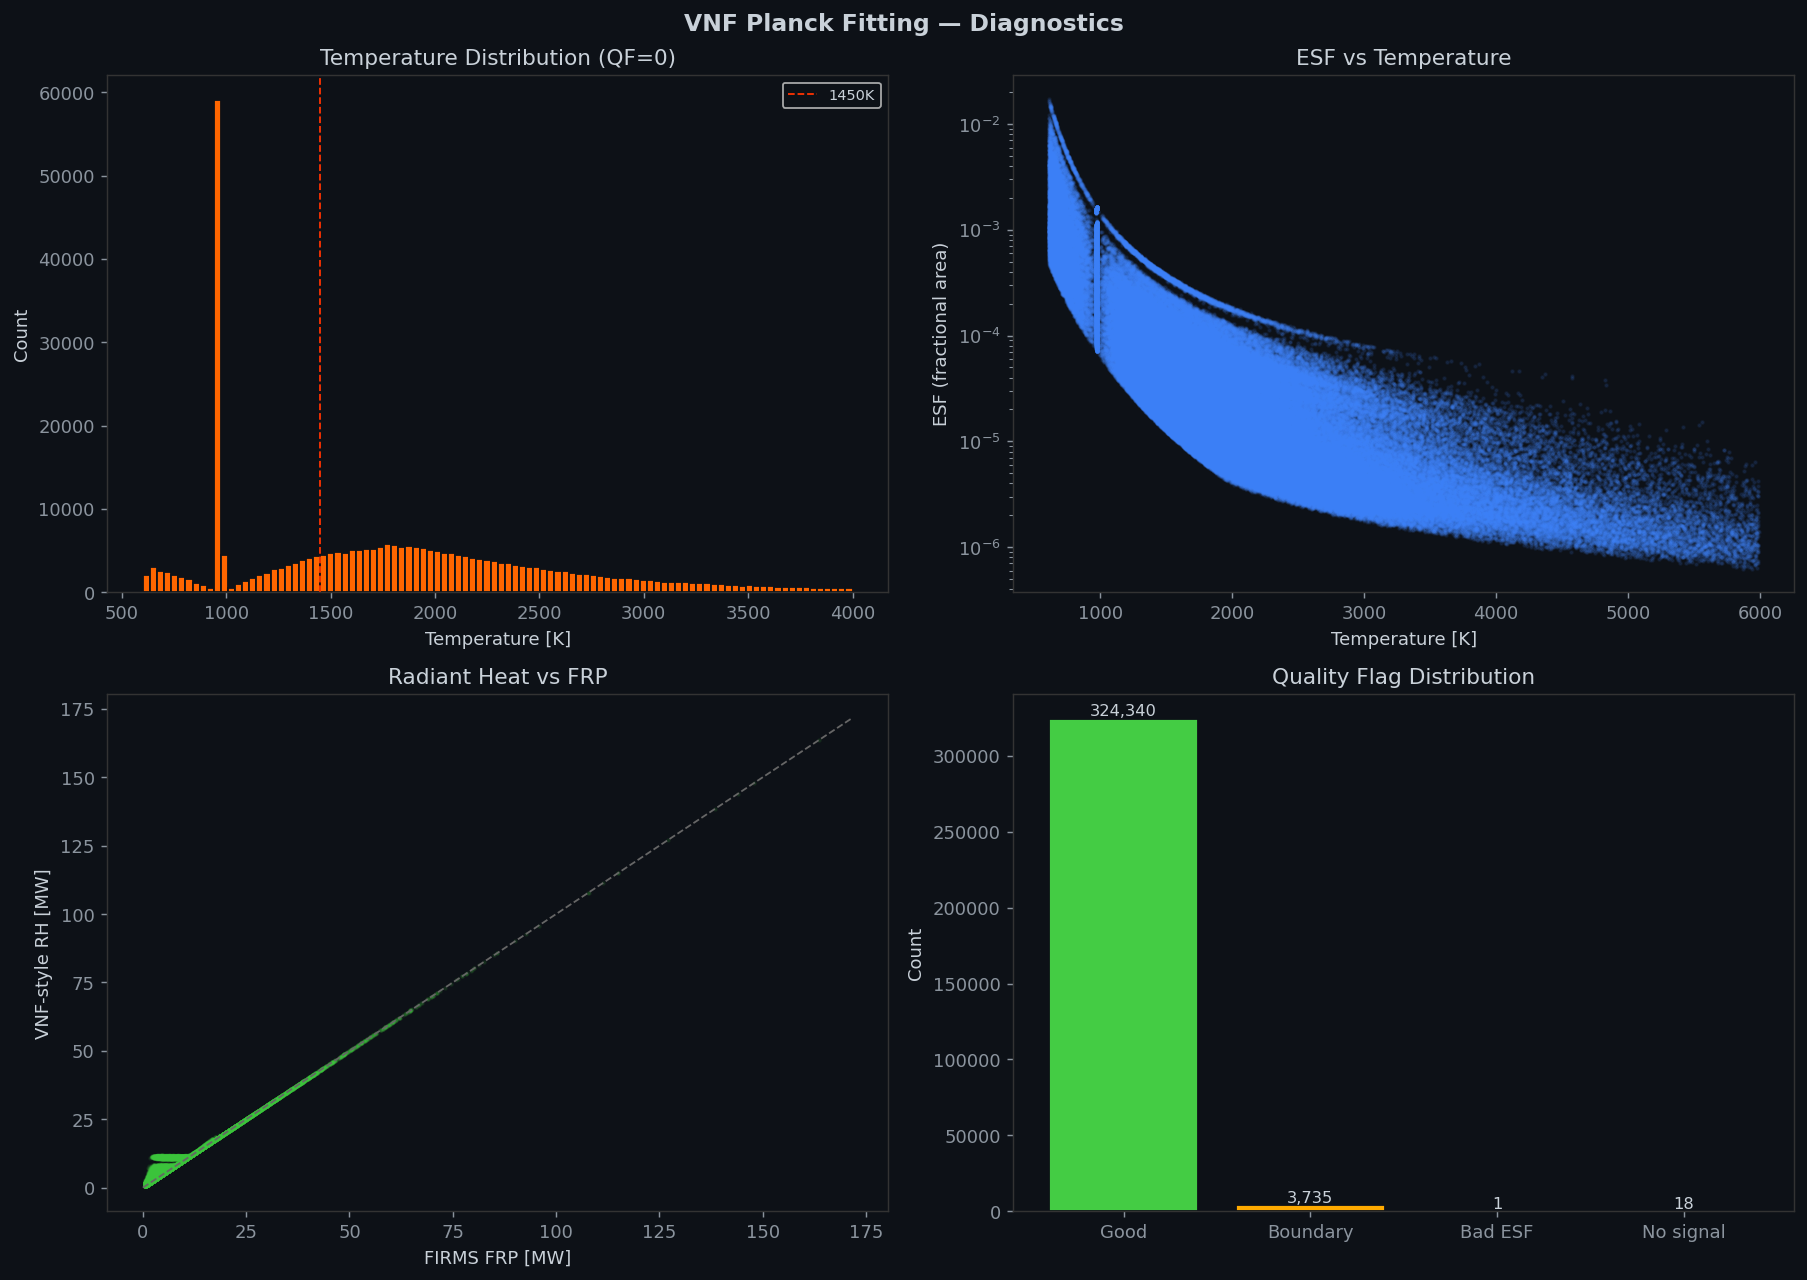

In [5]:
plot_diagnostics(df, save_path=OUTPUT_DIR / "diagnostics.png")

## 3. Monthly time series

In [6]:
timeseries = build_monthly_timeseries(df)
timeseries

country,Iran,Iraq,Saudi Arabia,Oman,Kuwait,Qatar,Yemen
month,,,,,,,
2022-10-01,26331,16355,3903,2566,955,254,0
2022-11-01,17114,11081,3689,2394,777,228,3
2022-12-01,16864,11741,3858,2425,900,218,0
2023-01-01,11740,10829,3057,1974,789,204,5
2023-02-01,14413,10216,3603,2095,695,226,1
2023-03-01,19781,11623,3809,2323,697,259,3
2023-04-01,24604,12532,3181,2012,708,248,1
2023-05-01,31048,15135,3772,2240,800,195,5
2023-06-01,6444,3476,879,544,226,43,3


## 4. Scale factors (parameters)

Multiply monthly detection counts per country.  
`1.0` = no change, `2.0` = double, `0.5` = halve.  
Countries not listed keep original values.

In [7]:
# ── EDIT THESE ──
SCALE_FACTORS = {
    "Iran":          1.0,
    "Iraq":          1.0,
    "Saudi Arabia":  1.0,
    "Oman":          1.0,
    "Kuwait":        1.0,
    "Qatar":         1.0,
    "Yemen":         1.0,
}

ts_scaled = apply_scale_factors(timeseries, SCALE_FACTORS)
ts_scaled

country,Iran,Iraq,Saudi Arabia,Oman,Kuwait,Qatar,Yemen
month,,,,,,,
2022-10-01,26331,16355,3903,2566,955,254,0
2022-11-01,17114,11081,3689,2394,777,228,3
2022-12-01,16864,11741,3858,2425,900,218,0
2023-01-01,11740,10829,3057,1974,789,204,5
2023-02-01,14413,10216,3603,2095,695,226,1
2023-03-01,19781,11623,3809,2323,697,259,3
2023-04-01,24604,12532,3181,2012,708,248,1
2023-05-01,31048,15135,3772,2240,800,195,5
2023-06-01,6444,3476,879,544,226,43,3


## 5. Bar plot — monthly time series

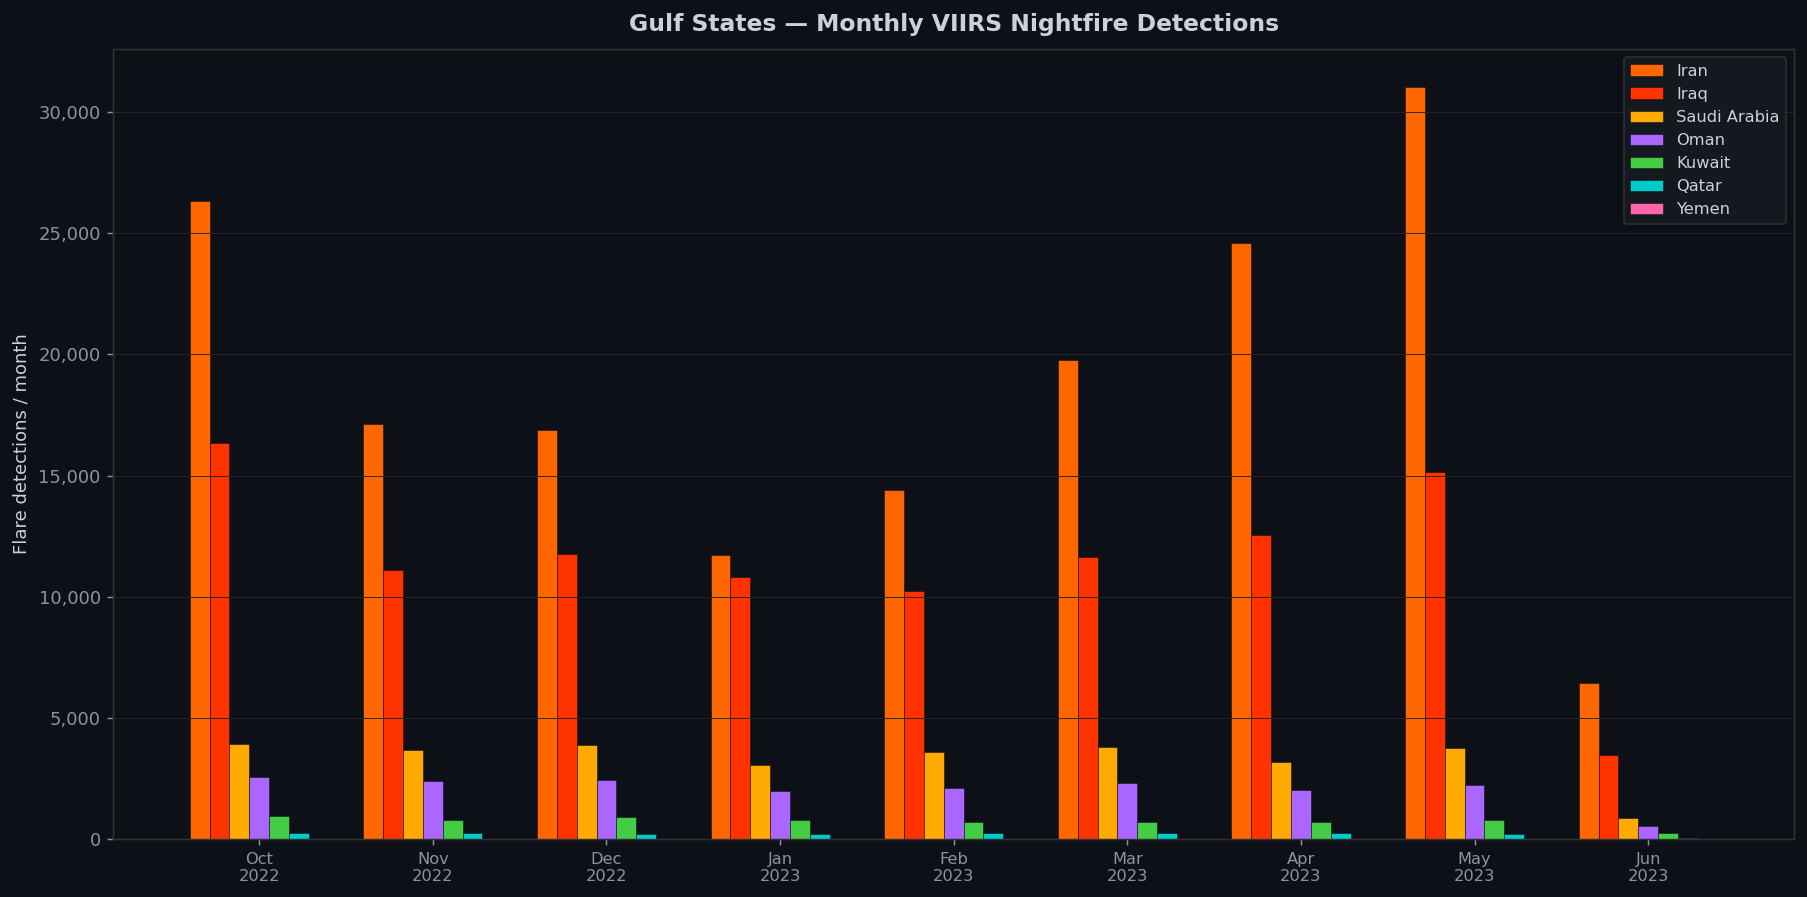

In [8]:
plot_timeseries_bars(
    ts_scaled,
    title="Gulf States — Monthly VIIRS Nightfire Detections",
    save_path=OUTPUT_DIR / "timeseries_bars.png",
)

## 6. Map — high temperature flares

High-temp (>1450K) detections 2023-06-01 to 2023-06-07: 8948


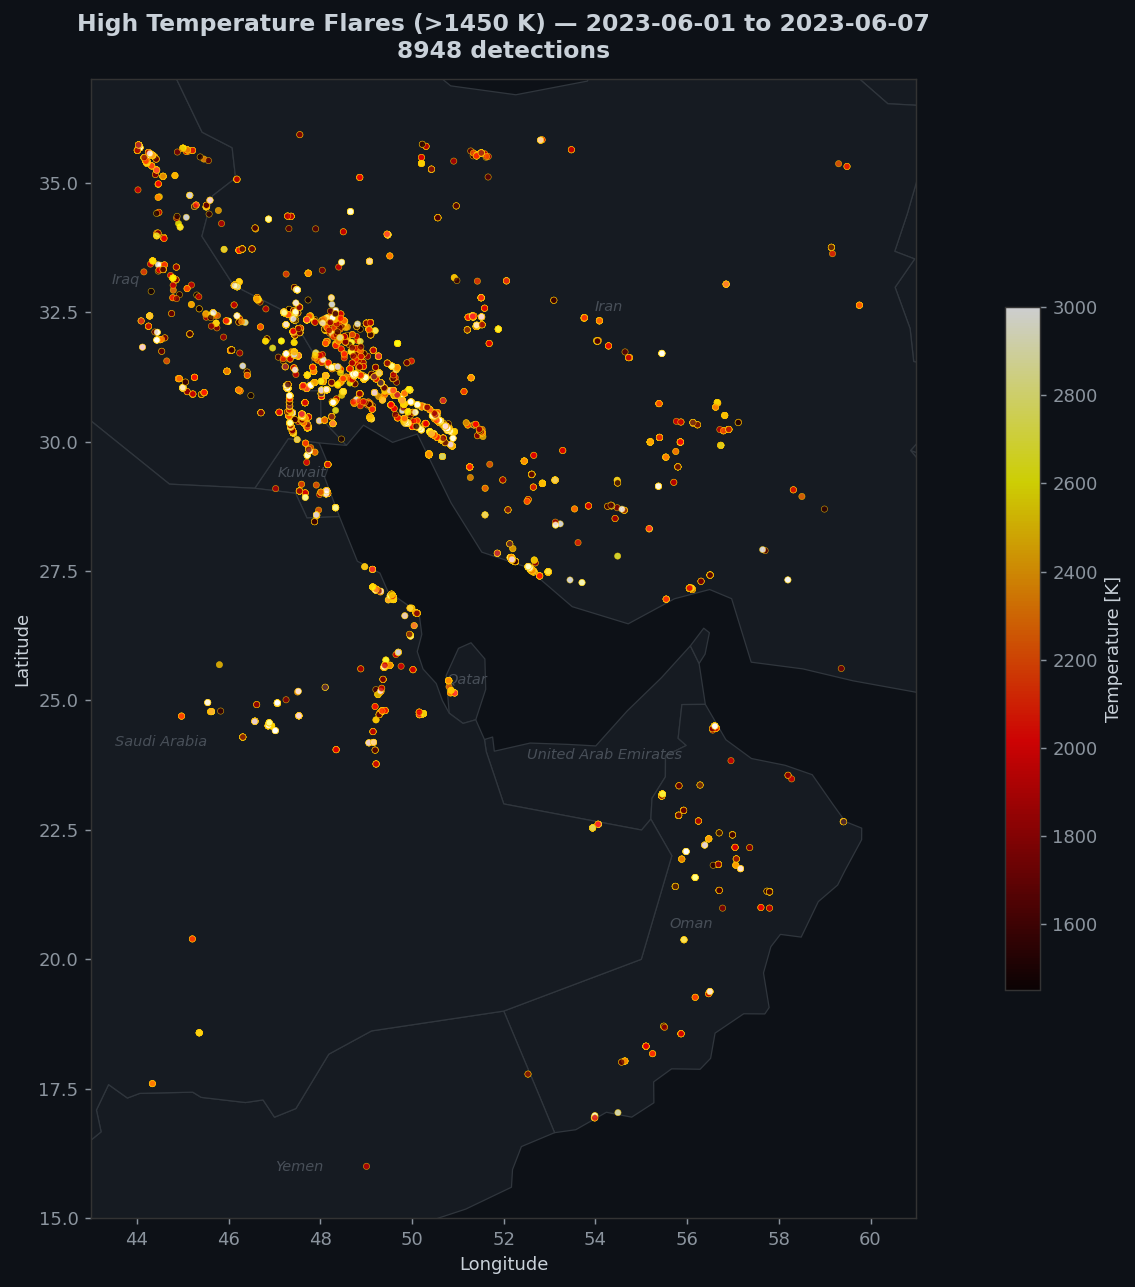

In [9]:
plot_hightemp_map(
    df,
    date_start=MAP_DATE_START,
    date_end=MAP_DATE_END,
    temp_col="Temp_BB",
    temp_threshold=1450,
    save_path=OUTPUT_DIR / "map_high_temp.png",
)

## 7. Export to CSV

In [10]:
export_csv(ts_scaled, OUTPUT_DIR / "monthly_timeseries.csv")

Exported: data\monthly_timeseries.csv


## 8. Calibration vs VNF reference (run when you have ref data)

Load VNF reference CSV, match detections spatially+temporally, compute metrics.

```python
# Example — uncomment when you have VNF reference data:
import pandas as pd
ref = pd.read_csv("data/vnf_reference.csv")   # VNF output CSV

# Manual comparison
metrics = compare_with_reference(df, ref)
plot_calibration(metrics, save_path=OUTPUT_DIR / "calibration.png")

# Auto-calibrate tau_i4, frp_scale, bg_offset to minimize RMSE
raw = pd.read_parquet(PARQUET_PATH)
best_cal, final_metrics = auto_calibrate(raw, ref, base_cal=cal)
best_cal.save("data/calibration.json")
plot_calibration(final_metrics, save_path=OUTPUT_DIR / "calibration_tuned.png")

# Re-run with tuned calibration
cal_tuned = CalibrationConfig.load("data/calibration.json")
df_tuned = load_and_process(PARQUET_PATH, COUNTRY_BBOX, cal=cal_tuned)
```